#Notebook feito por Ian Marques Breda
#Windows 11 home - python 3.12.5

In [ ]:
#Bibliotecas necessárias

import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [ ]:
#Transformação dos dados

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

#Download do dataset
train_data = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_data = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

#parâmetros de batch, épocas e proporção do conjunto de validação
batch = 32
num_epochs = 35
val_ratio = 0.1

#Divisão dos conjuntos e criação dos dataloaders
val_size = int(len(train_data) * val_ratio)
train_size = len(train_data) - val_size

train_subset, val_subset = random_split(train_data, [train_size, val_size])

train_loader = DataLoader(train_subset, batch_size=batch, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=batch, shuffle=False)

test_loader = DataLoader(test_data, batch_size=batch, shuffle=False)

print('Dados carregados \n')

Dados carregados 



In [ ]:
#Primeira arquitetura de CNN
#con1 32 filtros 3x3 - maxpooling 2x2 - conv2 64 filtros 3x3 - conv3 64 filtros 3x3
#dropout (10% ou 30%) - Entrada 1024 - FC1 64 - Saída 10
class ConvNet1(nn.Module):
    def __init__(self, drop):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 64, 3)
        self.conv3 = nn.Conv2d(64, 64, 3)
        self.dropout = nn.Dropout(p=drop)
        self.fc1 = nn.Linear(64*4*4, 64)
        self.fc2 = nn.Linear(64, 10)

    def forward(self, x):
        # N, 3, 32, 32
        x = F.relu(self.conv1(x))   
        x = self.pool(x)           
        x = F.relu(self.conv2(x)) 
        x = self.pool(x)          
        x = F.relu(self.conv3(x))  
        x = torch.flatten(x, 1)    
        x = self.dropout(F.relu(self.fc1(x)))     
        x = self.fc2(x)             
        return x

In [ ]:
#Segunda arquitetura de CNN
#conv1 32 filtros 3x3 - conv2 - 64 filtros 3x3 - maxpooling 2x2 - conv3 128 filtros 3x3
#conv4 128 filtros 3x3 - dropout (10% ou 30%) - Entrada 2048 - FC1 128 - FC2 64 - Saída 10
class ConvNet2(nn.Module):
    def __init__(self, drop):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3)    
        self.conv2 = nn.Conv2d(32, 64, 3)   
        self.pool = nn.MaxPool2d(2, 2)               
        self.conv3 = nn.Conv2d(64, 128, 3)  
        self.conv4 = nn.Conv2d(128, 128, 3) 
        self.dropout = nn.Dropout(p=drop)
        self.fc1 = nn.Linear(128*4*4, 128)
        self.fc_extra = nn.Linear(128, 64)  
        self.fc2 = nn.Linear(64, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))  
        x = F.relu(self.conv2(x))   
        x = self.pool(x)           
        x = F.relu(self.conv3(x))  
        x = self.pool(x)          
        x = F.relu(self.conv4(x))  
        x = torch.flatten(x, 1)     
        x = self.dropout(F.relu(self.fc1(x)))     
        x = self.dropout(F.relu(self.fc_extra(x))) 
        x = self.fc2(x)                             
        return x

In [ ]:
#Early stop para evitar overfitting
class EarlyStopping:
    def __init__(self, patience=3, min_delta=0.0001):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = float('inf')
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_loss - val_loss > self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True

In [ ]:
def experiment(modelo, drop, otim, num_epochs, index):

    #Salva os valores de loss do treinamento e validação para plotagem
    train_losses = []
    val_losses = []

    #Seleciona a arquitetura do modelo
    if modelo == 1:
        model = ConvNet1(drop)
    else:
        model = ConvNet2(drop)
    
    #Função de perda
    criterion = nn.CrossEntropyLoss()

    #Seleciona o otimizador
    if otim == 'sgd':
        learning_rate = 0.03
        optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
    else:
        learning_rate = 0.001
        optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    early_stopping = EarlyStopping(patience=3, min_delta=0.0001)
    n_total_steps = len(train_loader)

    print(f'Experimentando Modelo #{modelo} Otimizador: {otim.upper()} Dropout: {drop} learning rate: {learning_rate}')
    for epoch in range(num_epochs):

        #Coloca o modelo em modo de treino e inicia o treinamento
        model.train()
        running_loss = 0.0

        for i, (images, labels) in enumerate(train_loader):
            images = images
            labels = labels

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Backward e otimização dos pesos
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

            running_loss += loss.item()
        avg_train_loss = running_loss / len(train_loader)

        
        #Coloca o modelo em modo de validação
        model.eval()
        val_loss = 0.0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images, labels
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
        avg_val_loss = val_loss / len(val_loader)

        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)

        #Print da época, e loss de treino/teste
        print(f'Época [{epoch+1}/{num_epochs}], Treinamento Loss: {avg_train_loss:.4f}, Validação Loss: {avg_val_loss:.4f}')

        #No caso de early stop, salva o modelo utilizado para futura utilização
        early_stopping(avg_val_loss)
        if early_stopping.early_stop:
            print("Early stopping ativado!")
            path = 'modelo' + str(index) + '.pth'
            torch.save(model.state_dict(), path)
            break

    #Acurácia do modelo no conjunto de testes
    with torch.no_grad():
        model.eval()
        n_correct = 0
        n_samples = len(test_loader.dataset)

        for images, labels in test_loader:
            outputs = model(images)

            _, predicted = torch.max(outputs, 1)
            n_correct += (predicted == labels).sum().item()

        acc = 100.0 * n_correct / n_samples
        print(f'Acuracia do modelo: {acc}%')
    
    #Plotagem da loss de treino e validação
    plt.figure(figsize=(8, 5))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'Modelo {modelo} | Otimizador: {otim.upper()} | Dropout: {drop}')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    train_losses.clear()
    val_losses.clear()

Experimentando Modelo #1 Otimizador: SGD Dropout: 0.1 learning rate: 0.03
Época [1/35], Treinamento Loss: 1.9081, Validação Loss: 1.8587
Época [2/35], Treinamento Loss: 1.4747, Validação Loss: 1.4290
Época [3/35], Treinamento Loss: 1.2930, Validação Loss: 1.8371
Época [4/35], Treinamento Loss: 1.1598, Validação Loss: 1.4138
Época [5/35], Treinamento Loss: 1.0496, Validação Loss: 1.0751
Época [6/35], Treinamento Loss: 0.9521, Validação Loss: 0.9551
Época [7/35], Treinamento Loss: 0.8798, Validação Loss: 0.9711
Época [8/35], Treinamento Loss: 0.8150, Validação Loss: 0.8817
Época [9/35], Treinamento Loss: 0.7633, Validação Loss: 1.1808
Época [10/35], Treinamento Loss: 0.7096, Validação Loss: 0.8923
Época [11/35], Treinamento Loss: 0.6628, Validação Loss: 0.9986
Early stopping ativado!
Acuracia do modelo: 66.94%


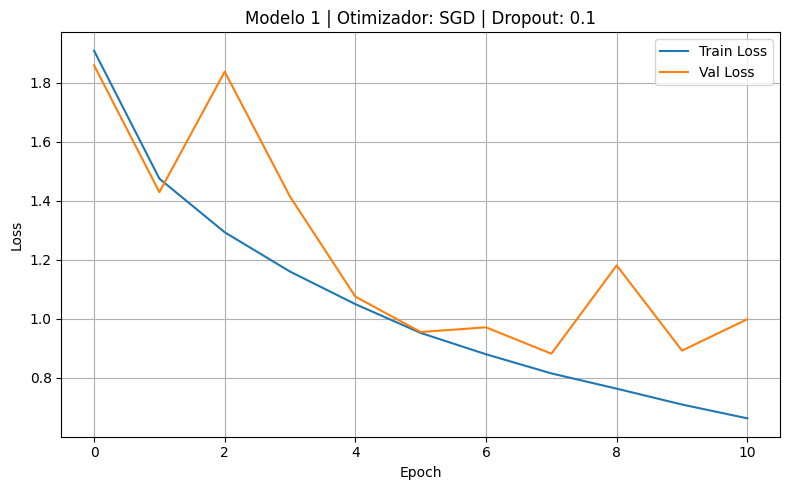



Experimentando Modelo #1 Otimizador: ADAM Dropout: 0.1 learning rate: 0.001
Época [1/35], Treinamento Loss: 1.5249, Validação Loss: 1.2986
Época [2/35], Treinamento Loss: 1.1844, Validação Loss: 1.0787
Época [3/35], Treinamento Loss: 1.0280, Validação Loss: 1.0150
Época [4/35], Treinamento Loss: 0.9222, Validação Loss: 0.9172
Época [5/35], Treinamento Loss: 0.8477, Validação Loss: 0.8740
Época [6/35], Treinamento Loss: 0.7801, Validação Loss: 0.9044
Época [7/35], Treinamento Loss: 0.7295, Validação Loss: 0.8653
Época [8/35], Treinamento Loss: 0.6862, Validação Loss: 0.8148
Época [9/35], Treinamento Loss: 0.6456, Validação Loss: 0.8376
Época [10/35], Treinamento Loss: 0.6060, Validação Loss: 0.8638
Época [11/35], Treinamento Loss: 0.5741, Validação Loss: 0.8639
Early stopping ativado!
Acuracia do modelo: 72.05%


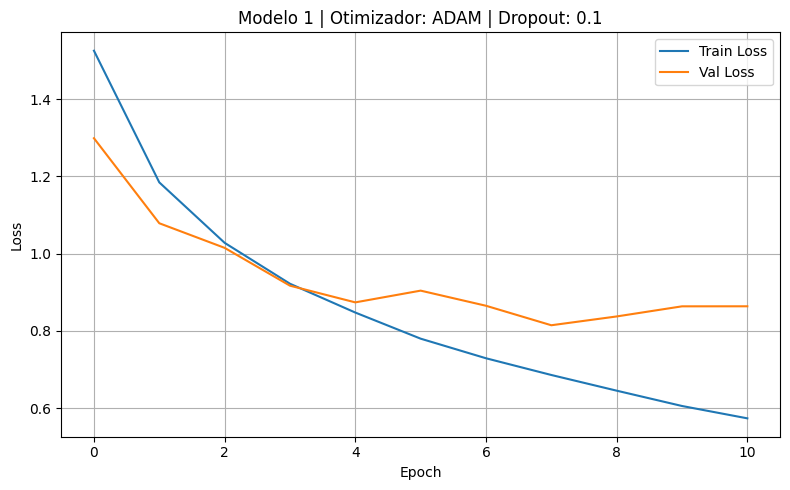



Experimentando Modelo #1 Otimizador: SGD Dropout: 0.3 learning rate: 0.03
Época [1/35], Treinamento Loss: 1.9183, Validação Loss: 1.7659
Época [2/35], Treinamento Loss: 1.5373, Validação Loss: 1.6526
Época [3/35], Treinamento Loss: 1.3553, Validação Loss: 1.2458
Época [4/35], Treinamento Loss: 1.2234, Validação Loss: 1.2832
Época [5/35], Treinamento Loss: 1.1167, Validação Loss: 1.1398
Época [6/35], Treinamento Loss: 1.0328, Validação Loss: 1.0640
Época [7/35], Treinamento Loss: 0.9590, Validação Loss: 1.2772
Época [8/35], Treinamento Loss: 0.8972, Validação Loss: 0.8784
Época [9/35], Treinamento Loss: 0.8391, Validação Loss: 0.8698
Época [10/35], Treinamento Loss: 0.7932, Validação Loss: 0.9760
Época [11/35], Treinamento Loss: 0.7490, Validação Loss: 1.0157
Época [12/35], Treinamento Loss: 0.7096, Validação Loss: 0.8988
Early stopping ativado!
Acuracia do modelo: 69.31%


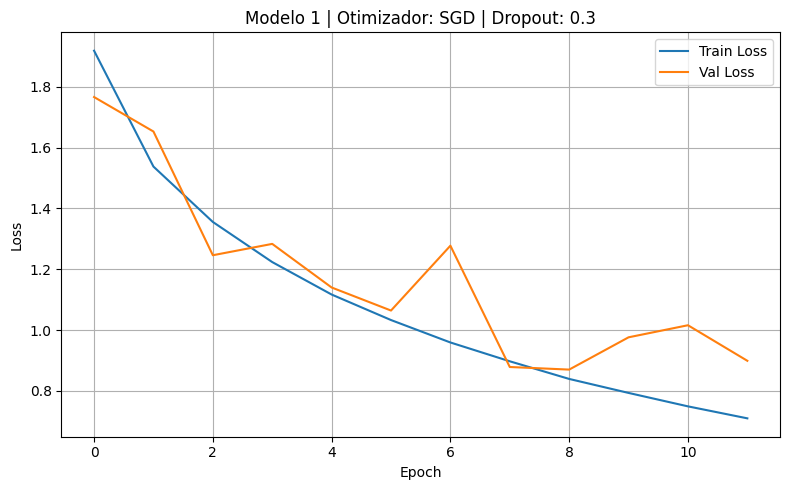



Experimentando Modelo #1 Otimizador: ADAM Dropout: 0.3 learning rate: 0.001
Época [1/35], Treinamento Loss: 1.6334, Validação Loss: 1.3415
Época [2/35], Treinamento Loss: 1.3128, Validação Loss: 1.1719
Época [3/35], Treinamento Loss: 1.1602, Validação Loss: 1.0295
Época [4/35], Treinamento Loss: 1.0467, Validação Loss: 1.0313
Época [5/35], Treinamento Loss: 0.9623, Validação Loss: 0.9452
Época [6/35], Treinamento Loss: 0.8977, Validação Loss: 0.9138
Época [7/35], Treinamento Loss: 0.8507, Validação Loss: 0.8485
Época [8/35], Treinamento Loss: 0.8089, Validação Loss: 0.8317
Época [9/35], Treinamento Loss: 0.7731, Validação Loss: 0.8237
Época [10/35], Treinamento Loss: 0.7415, Validação Loss: 0.8248
Época [11/35], Treinamento Loss: 0.7142, Validação Loss: 0.8115
Época [12/35], Treinamento Loss: 0.6863, Validação Loss: 0.8224
Época [13/35], Treinamento Loss: 0.6693, Validação Loss: 0.8184
Época [14/35], Treinamento Loss: 0.6446, Validação Loss: 0.8464
Early stopping ativado!
Acuracia do

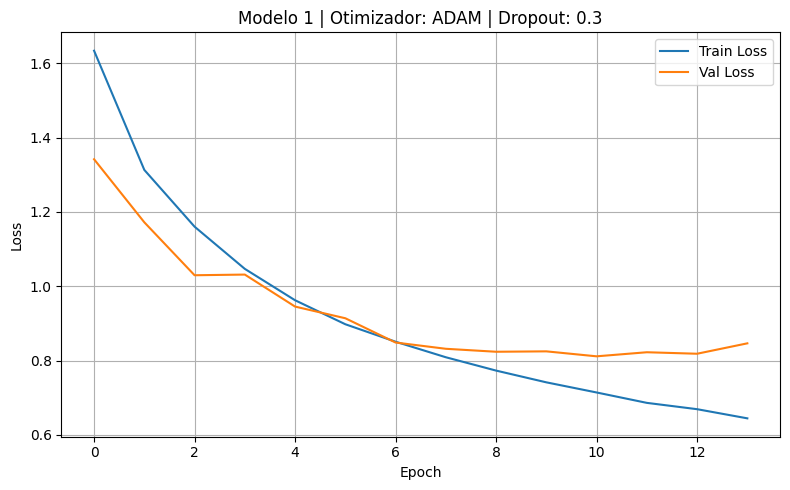



Experimentando Modelo #2 Otimizador: SGD Dropout: 0.1 learning rate: 0.03
Época [1/35], Treinamento Loss: 2.2238, Validação Loss: 1.9126
Época [2/35], Treinamento Loss: 1.7336, Validação Loss: 1.6737
Época [3/35], Treinamento Loss: 1.4661, Validação Loss: 1.3898
Época [4/35], Treinamento Loss: 1.2700, Validação Loss: 1.3219
Época [5/35], Treinamento Loss: 1.0985, Validação Loss: 1.1389
Época [6/35], Treinamento Loss: 0.9560, Validação Loss: 0.9742
Época [7/35], Treinamento Loss: 0.8291, Validação Loss: 1.1692
Época [8/35], Treinamento Loss: 0.7348, Validação Loss: 0.8009
Época [9/35], Treinamento Loss: 0.6539, Validação Loss: 0.7606
Época [10/35], Treinamento Loss: 0.5752, Validação Loss: 1.0439
Época [11/35], Treinamento Loss: 0.5137, Validação Loss: 0.8085
Época [12/35], Treinamento Loss: 0.4503, Validação Loss: 0.7487
Época [13/35], Treinamento Loss: 0.3909, Validação Loss: 0.8335
Época [14/35], Treinamento Loss: 0.3356, Validação Loss: 0.8382
Época [15/35], Treinamento Loss: 0.29

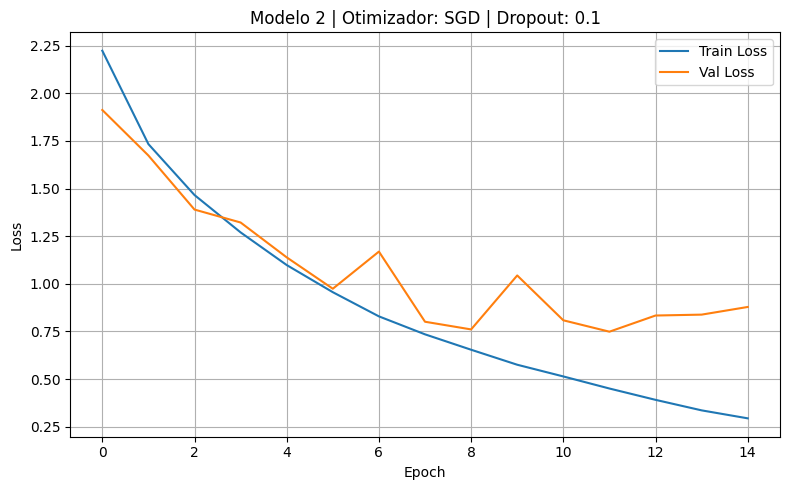



Experimentando Modelo #2 Otimizador: ADAM Dropout: 0.1 learning rate: 0.001
Época [1/35], Treinamento Loss: 1.5616, Validação Loss: 1.1899
Época [2/35], Treinamento Loss: 1.0927, Validação Loss: 0.9609
Época [3/35], Treinamento Loss: 0.8740, Validação Loss: 0.8483
Época [4/35], Treinamento Loss: 0.7367, Validação Loss: 0.7855
Época [5/35], Treinamento Loss: 0.6376, Validação Loss: 0.7696
Época [6/35], Treinamento Loss: 0.5593, Validação Loss: 0.7187
Época [7/35], Treinamento Loss: 0.4894, Validação Loss: 0.7467
Época [8/35], Treinamento Loss: 0.4362, Validação Loss: 0.7705
Época [9/35], Treinamento Loss: 0.3812, Validação Loss: 0.7906
Early stopping ativado!
Acuracia do modelo: 76.22%


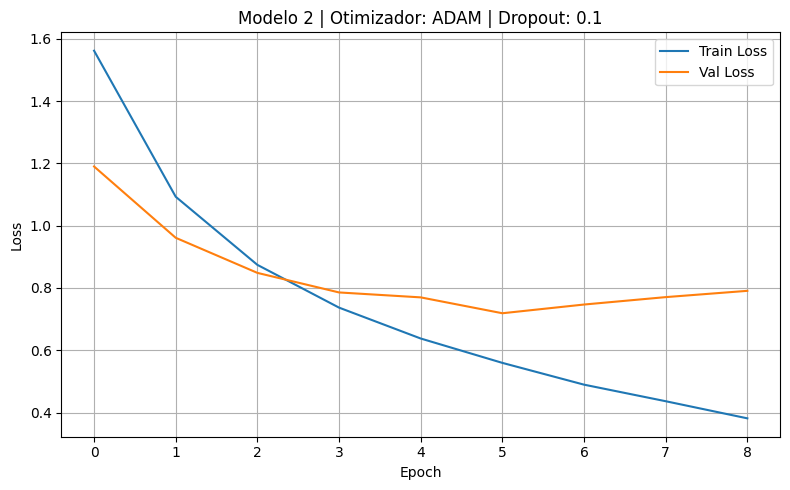



Experimentando Modelo #2 Otimizador: SGD Dropout: 0.3 learning rate: 0.03
Época [1/35], Treinamento Loss: 2.2603, Validação Loss: 2.0259
Época [2/35], Treinamento Loss: 1.8553, Validação Loss: 1.7152
Época [3/35], Treinamento Loss: 1.5894, Validação Loss: 1.4342
Época [4/35], Treinamento Loss: 1.4070, Validação Loss: 1.3143
Época [5/35], Treinamento Loss: 1.2426, Validação Loss: 1.2984
Época [6/35], Treinamento Loss: 1.0914, Validação Loss: 1.0782
Época [7/35], Treinamento Loss: 0.9657, Validação Loss: 1.3459
Época [8/35], Treinamento Loss: 0.8746, Validação Loss: 0.8663
Época [9/35], Treinamento Loss: 0.7907, Validação Loss: 0.8695
Época [10/35], Treinamento Loss: 0.7202, Validação Loss: 0.7791
Época [11/35], Treinamento Loss: 0.6557, Validação Loss: 1.4228
Época [12/35], Treinamento Loss: 0.5955, Validação Loss: 1.0431
Época [13/35], Treinamento Loss: 0.5433, Validação Loss: 0.7905
Early stopping ativado!
Acuracia do modelo: 74.91%


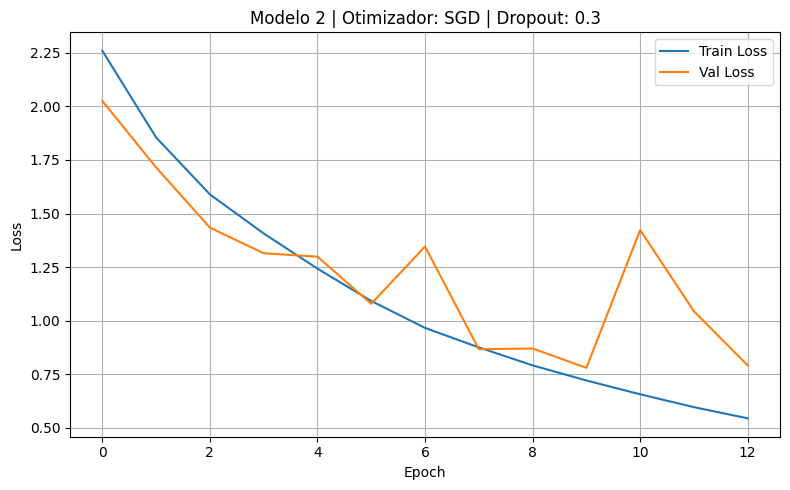



Experimentando Modelo #2 Otimizador: ADAM Dropout: 0.3 learning rate: 0.001
Época [1/35], Treinamento Loss: 1.6890, Validação Loss: 1.3238
Época [2/35], Treinamento Loss: 1.2281, Validação Loss: 1.0405
Época [3/35], Treinamento Loss: 1.0168, Validação Loss: 0.9277
Época [4/35], Treinamento Loss: 0.8897, Validação Loss: 0.8236
Época [5/35], Treinamento Loss: 0.7974, Validação Loss: 0.8039
Época [6/35], Treinamento Loss: 0.7153, Validação Loss: 0.7784
Época [7/35], Treinamento Loss: 0.6516, Validação Loss: 0.7839
Época [8/35], Treinamento Loss: 0.6001, Validação Loss: 0.7861
Época [9/35], Treinamento Loss: 0.5518, Validação Loss: 0.7913
Early stopping ativado!
Acuracia do modelo: 74.74%


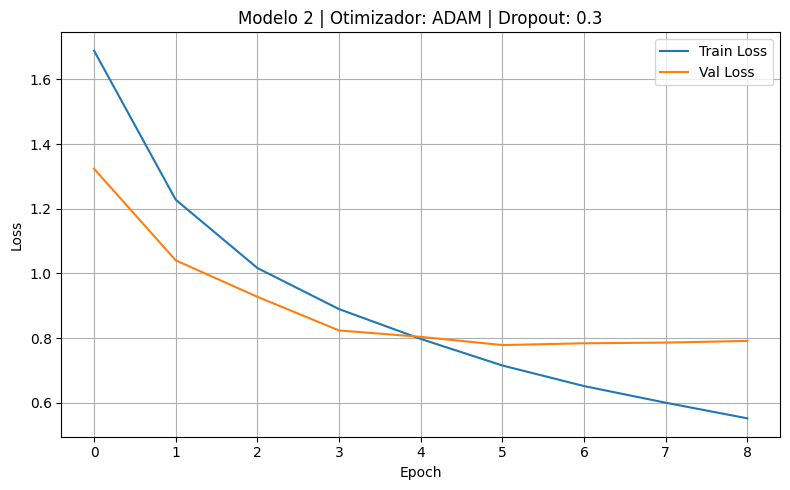

In [ ]:
#Chama a função experiment levando diferentes configurações de otimizador, dropout e arquitetura
otimizador = ['sgd', 'adam']
drop_out = [0.1, 0.3]
modelo = [1, 2]
index = 1

for mod in modelo:
    for drop in drop_out:
        for otim in otimizador:
            experiment(mod, drop, otim, num_epochs, index)
            print('\n==================================================================\n')
            index += 1

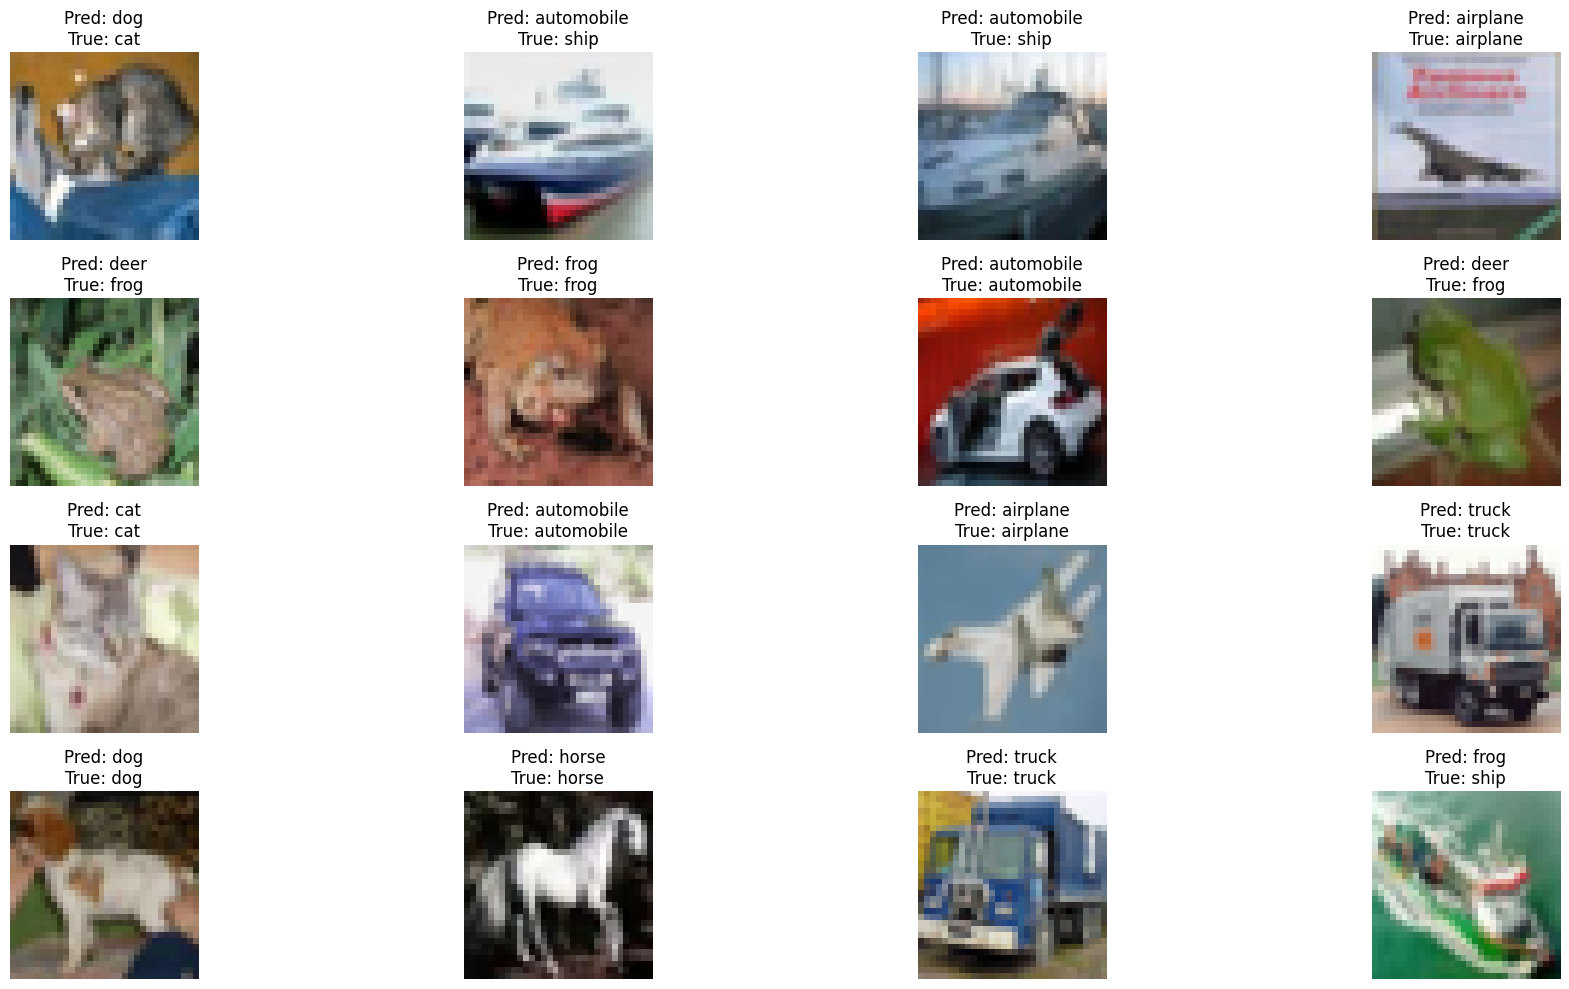

In [ ]:
#Caminho do modelo salvo
model_path = 'modelo2.pth' #modelos de 1 a 8
modelo_num = 1  #Escolha: 1 para modelo de 1 a 4 ou 2 para modelo de 5 a 8
drop = 0 

#Inicializa o modelo com o mesmo tipo de arquitetura usada no treinamento
if modelo_num == 1:
    model = ConvNet1(drop)
elif modelo_num == 2:
    model = ConvNet2(drop)

#Carrega os pesos treinados
model.load_state_dict(torch.load(model_path))
model.eval()

#Classes do CIFAR-10
classes = train_data.classes

#Pega algumas imagens do conjunto de teste, iterando sobre ele
dataiter = iter(test_loader)
images, labels = next(dataiter)

#Faz previsões
with torch.no_grad():
    outputs = model(images)
    _, preds = torch.max(outputs, 1)

#Plota 16 imagens com rótulos preditos e verdadeiros
fig, axes = plt.subplots(4, 4, figsize=(20, 10))
axes = axes.flatten()

for idx in range(16):
    image = images[idx] * 0.5 + 0.5  #Desfaz normalização da segunda célula: (-1,1) → (0,1)
    npimg = image.numpy()
    axes[idx].imshow(np.transpose(npimg, (1, 2, 0)))
    axes[idx].set_title(f'Pred: {classes[preds[idx]]}\nTrue: {classes[labels[idx]]}')
    axes[idx].axis('off')

plt.tight_layout()
plt.show()
